In [8]:
# 自己实现数据集加载训练
import torch
from torch import nn
from torchsummary import summary
import torch.utils.data as Data
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.nn import functional as F
import torch.nn as nn


In [9]:
# 数据集构建
train_path = r'train' # 数据集存放路径
# 定义数据预处理操作
data_transform = transforms.Compose([
    transforms.Resize((227,227)), # 调整图像大小
    transforms.ToTensor(), # 转为张量
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))]) # 标准化
# 加载数据集
train_transform = ImageFolder(root=train_path, transform=data_transform)
print(train_transform.class_to_idx) # 打印类别标签映射

# 划分训练集和验证集 
train_data,val_data = Data.random_split(dataset=train_transform,lengths=[round(0.8*len(train_transform)),round(0.2*len(train_transform))])
train_loader = Data.DataLoader(dataset=train_data,batch_size=256,shuffle=True,num_workers=0)
val_loader = Data.DataLoader(dataset=val_data,batch_size=256,shuffle=False,num_workers=0)
# 获得一个batch的数据
i=1
for batch_idx,(data,target) in enumerate(train_loader):
    if i>0:
      print(data.shape)
      print(target.shape)
      i-=1
    if batch_idx > 0:
      break
    batch_x = data.squeeze().numpy()#将四维张亮去掉第一维
    batch_y=target.numpy()
    class_label = train_data.dataset.classes#训练集的类别标签
    # 打印数据形状    
    print(batch_x.shape)
    print(batch_y.shape)
    print(class_label)


{'Apple': 0, 'Banana': 1, 'Grape': 2, 'Mango': 3, 'Strawberry': 4}
torch.Size([256, 3, 227, 227])
torch.Size([256])
(256, 3, 227, 227)
(256,)
['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']


In [10]:
class AlexNet(nn.Module):
    def __init__(self):
        super(AlexNet,self).__init__()
        self.ReLu = nn.ReLU()
        self.c1 = nn.Conv2d(in_channels=3,out_channels=96,kernel_size=11,stride=4)
        self.s1 = nn.MaxPool2d(kernel_size=3,stride=2)
        self.c2 = nn.Conv2d(in_channels=96,out_channels=256,kernel_size=5,padding=2)
        self.s2 = nn.MaxPool2d(kernel_size=3,stride=2)
        self.c3 = nn.Conv2d(in_channels=256,out_channels=384,kernel_size=3,padding=1)
        self.c4 = nn.Conv2d(in_channels=384,out_channels=384,kernel_size=3,padding=1)
        self.c5 = nn.Conv2d(in_channels=384,out_channels=256,kernel_size=3,padding=1)
        self.s3 = nn.MaxPool2d(kernel_size=3,stride=2)
        self.flatten = nn.Flatten()
        self.l1 = nn.Linear(in_features=256*6*6,out_features=4096)#这里的input_features是上一个层的输出
        self.l2 = nn.Linear(in_features=4096,out_features=4096)
        self.l3 = nn.Linear(in_features=4096,out_features=5) #最后输出5类
        # 初始化权重
        for m in self.modules():
            if isinstance(m,nn.Conv2d):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m,nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    def forward(self,x):
        x= self.c1(x)
        x= self.ReLu(x)
        x= self.s1(x)
        x= self.c2(x)
        x= self.ReLu(x)
        x= self.s2(x)
        x= self.c3(x)
        x= self.ReLu(x)
        x= self.c4(x)
        x = self.ReLu(x)
        x=self.c5(x)
        x= self.ReLu(x)
        x=self.s3(x)
        x= self.flatten(x)
        x= self.l1(x)
        x= self.ReLu(x)
        x =F.dropout(x,0.5)
        x = self.l2(x)
        x= self.ReLu(x)
        x =F.dropout(x,0.5)
        x =self.l3(x)
        return x
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AlexNet().to(device)
summary(model,(3,227,227))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 96, 55, 55]          34,944
              ReLU-2           [-1, 96, 55, 55]               0
         MaxPool2d-3           [-1, 96, 27, 27]               0
            Conv2d-4          [-1, 256, 27, 27]         614,656
              ReLU-5          [-1, 256, 27, 27]               0
         MaxPool2d-6          [-1, 256, 13, 13]               0
            Conv2d-7          [-1, 384, 13, 13]         885,120
              ReLU-8          [-1, 384, 13, 13]               0
            Conv2d-9          [-1, 384, 13, 13]       1,327,488
             ReLU-10          [-1, 384, 13, 13]               0
           Conv2d-11          [-1, 256, 13, 13]         884,992
             ReLU-12          [-1, 256, 13, 13]               0
        MaxPool2d-13            [-1, 256, 6, 6]               0
          Flatten-14                 [-

In [11]:
# 定义优化器和损失函数
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
criterion =nn.CrossEntropyLoss()#交叉熵用于分类


In [12]:
import pandas as pd
import copy
import torch
from torch.nn.modules import loss
from tqdm import tqdm 
import time

# 训练
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
train_loss_all = []
val_loss_all = []
train_acc_all = []
val_acc_all = []
epoch_num = 20

# ================= 1: 这里包裹最外层的 range =================
# total=epoch_num, unit='epoch' 让进度条显示为 "进度: 1/20 [00:10<03:00, ...]"
main_loop = tqdm(range(epoch_num), desc="Total Training", unit='epoch')

for epoch in main_loop:
    # 初始化每一轮的参数
    train_loss = 0.0
    train_acc = 0.0
    val_loss = 0.0
    val_acc = 0.0
    train_num = 0
    val_num = 0     
    # ================= 训练阶段 =================
    model.train()
    for step, (b_x, b_y) in enumerate(train_loader): 
        b_x = b_x.to(device)
        b_y = b_y.to(device)
        
        optimizer.zero_grad()
        output = model(b_x)
        pre_label = torch.argmax(output, 1)
        loss = criterion(output, b_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * b_x.size(0)
        train_acc += torch.sum(pre_label == b_y.data)
        train_num += b_x.size(0)

    # ================= 验证阶段 =================
    model.eval()
    for step, (b_x, b_y) in enumerate(val_loader):
        b_x = b_x.to(device)
        b_y = b_y.to(device)
        
        with torch.no_grad():
            output = model(b_x)
            pre_label = torch.argmax(output, 1)
            loss = criterion(output, b_y)
            val_loss += loss.item() * b_x.size(0)
            val_acc += torch.sum(pre_label == b_y.data)
            val_num += b_x.size(0)

    # 计算平均指标
    epoch_train_loss = train_loss / train_num
    epoch_train_acc = train_acc.double() / train_num
    epoch_val_loss = val_loss / val_num
    epoch_val_acc = val_acc.double() / val_num

    train_loss_all.append(epoch_train_loss)
    train_acc_all.append(epoch_train_acc)
    val_loss_all.append(epoch_val_loss)
    val_acc_all.append(epoch_val_acc)

    # 深度拷贝模型
    if epoch_val_acc > best_acc:
        best_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    # ================= 修改点 2: 在总进度条后面显示本轮结果 =================
    # 这样你就不用 print 了，直接看进度条末尾的数字即可
    main_loop.set_postfix(
        train_loss=f"{epoch_train_loss:.4f}", 
        train_acc=f"{epoch_train_acc:.4f}",
        val_acc=f"{epoch_val_acc:.4f}"
    )

# 保存模型
torch.save(best_model_wts, 'best_model.pth')

# 数据转换处理
train_process = pd.DataFrame(data={
    "epoch": range(epoch_num),
    "train_loss": train_loss_all,
    "val_loss": val_loss_all,
    "train_acc": [x.cpu().item() if isinstance(x, torch.Tensor) else x for x in train_acc_all],
    "val_acc": [x.cpu().item() if isinstance(x, torch.Tensor) else x for x in val_acc_all]
})

print("Training Complete. Data saved.")

Total Training: 100%|██████████| 20/20 [25:47<00:00, 77.38s/epoch, train_acc=0.1965, train_loss=1.6096, val_acc=0.1907]


Training Complete. Data saved.


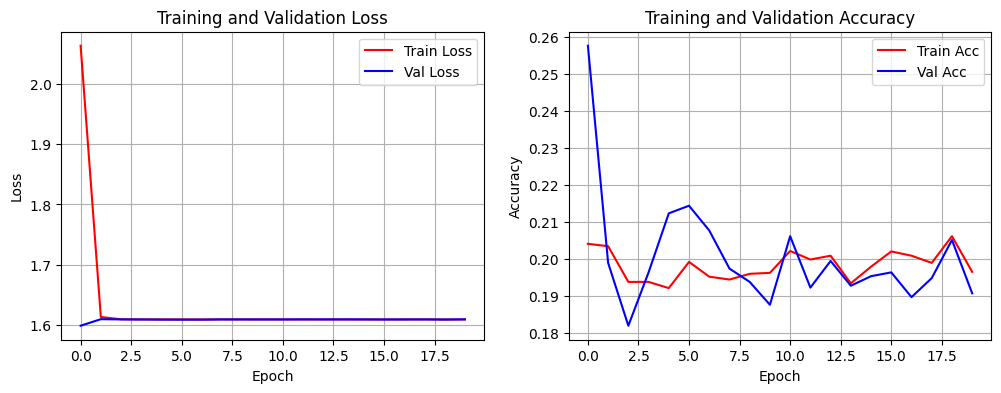

In [13]:
# ==========================================
# 3. 开始画图 (Matplotlib)
# ==========================================
plt.figure(figsize=(12, 4)) # 设置画布大小：宽12，高4

# --- 第一张图：Loss (损失率) ---
plt.subplot(1, 2, 1) # 1行2列，第1张图
plt.plot(train_process['epoch'], train_process['train_loss'], 'r', label='Train Loss') # 红线
plt.plot(train_process['epoch'], train_process['val_loss'], 'b', label='Val Loss')   # 蓝线
plt.legend() # 显示图例
plt.grid(True) # 显示网格
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

# --- 第二张图：Accuracy (准确率) ---
plt.subplot(1, 2, 2) # 1行2列，第2张图
plt.plot(train_process['epoch'], train_process['train_acc'], 'r', label='Train Acc')
plt.plot(train_process['epoch'], train_process['val_acc'], 'b', label='Val Acc')
plt.legend()
plt.grid(True)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

# 显示图表
plt.show()


In [15]:
# 预测展示
# 加载最佳模型权重
# 计算测试集准确率
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load('best_model.pth',weights_only=True))
model.to(device)
model.eval()

test_data = transforms.Compose([transforms.Resize((227,227)), transforms.ToTensor(), transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))])
test_loader = ImageFolder(root=r'test', transform=test_data)
test_loader = Data.DataLoader(dataset=test_loader,batch_size=1,shuffle=False,num_workers=0)

correct = 0
total = 0
with torch.no_grad():#在测试时不计算梯度，节省内存
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)#第0维度的大小，即batch_size

print(f"Test Acc: {correct/total:.4f}")


Test Acc: 0.2500


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

def predict_single_image(image_path, model, device, class_mapping):
    """
    单张图片推理函数
    :param image_path: 图片路径
    :param model: 已加载权重的模型
    :param device: 设备 (cpu/cuda)
    :param class_mapping: 类别索引映射 {0: 'cat', 1: 'dog'}
    """
    
    # 1. 使用 PIL 读取图片
    # .convert('RGB') 很重要，防止读取到 RGBA (透明通道) 导致报错
    try:
        img_pil = Image.open(image_path).convert('RGB')
    except FileNotFoundError:
        print(f"❌ 错误：找不到文件 {image_path}")
        return

    # 2. 定义预处理 (必须和训练时完全一致！)
    # 注意：这里不需要 RandomCrop 或 Flip，只需要 Resize -> ToTensor -> Normalize
    inference_transform = transforms.Compose([
        transforms.Resize((227, 227)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # 3. 处理图片
    img_tensor = inference_transform(img_pil)
    
    # 4. 增加 Batch 维度 [C, H, W] -> [1, C, H, W]
    # 神经网络输入必须是 4 维的
    img_tensor = img_tensor.unsqueeze(0).to(device)

    # 5. 推理
    model.eval() # 切换到评估模式 (关闭 Dropout 等)
    with torch.no_grad():
        output = model(img_tensor)
        
        # 使用 Softmax 将输出转换为概率分布
        probs = F.softmax(output, dim=1)
        
        # 获取最大概率的索引和值
        pred_idx = torch.argmax(output, dim=1).item()
        pred_prob = probs[0][pred_idx].item()

    # 6. 获取类别名称
    pred_class_name = class_mapping[pred_idx]

    # 7. 可视化展示
    plt.figure(figsize=(6, 6))
    plt.imshow(img_pil)
    plt.axis('off') # 不显示坐标轴
    plt.title(f"Prediction: {pred_class_name}\nConfidence: {pred_prob:.2%}")
    plt.show()

    print("="*30)
    print(f"🖼️ 图片路径: {image_path}")
    print(f"🧠 预测类别: {pred_class_name}")
    print(f"📊 置信度 (概率): {pred_prob:.4f}")
    print("="*30)

# ================= 使用示例 =================

# 1. 准备类别映射 (反转之前的 class_to_idx)
# train_transform.class_to_idx 长这样: {'cat': 0, 'dog': 1}
# 我们需要把它变成: {0: 'cat', 1: 'dog'}
idx_to_class = {v: k for k, v in train_transform.class_to_idx.items()}

# 2. 指定你要预测的图片路径 (⚠️请修改为你电脑上的实际图片路径⚠️)
# 比如你可以找一张网上下载的猫或狗的图片
# target_image_path = r'1.jfif' 

# 3. 确保模型已经加载了最佳权重 (你之前的代码里已经加载过了，这里为了保险再确认一下)
# model.load_state_dict(torch.load('best_model.pth', weights_only=True))
# model.to(device)

# 4. 执行预测
# predict_single_image(target_image_path, model, device, idx_to_class)